# Variabili d'ambiente


In [98]:
import os
import pandas as pd
import requests
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import seaborn as sns
import calendar as cal
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

load_dotenv(override=True)
token = os.getenv("NOTION_TOKEN").strip()
Musc = os.getenv("Musc").strip()
Wei = os.getenv("Wei").strip()
Exce = os.getenv("Exce").strip()
HEADERS = {
    "Authorization": f"Bearer {token}",
    "Notion-Version": "2025-09-03",
    "Content-Type": "application/json"
}

## Creazione Funzioni per creare i dataframe a partire dai 3 dataset di notion

In [99]:


def extract_property(prop: dict, relation_map: dict = {}):
    ptype = prop["type"]
    extractors = {
        "title":        lambda p: p["title"][0]["plain_text"] if p["title"] else None,
        "rich_text":    lambda p: p["rich_text"][0]["plain_text"] if p["rich_text"] else None,
        "number":       lambda p: p["number"],
        "select":       lambda p: p["select"]["name"] if p["select"] else None,
        "multi_select": lambda p: [s["name"] for s in p["multi_select"]],
        "date":         lambda p: p["date"]["start"] if p["date"] else None,
        "checkbox":     lambda p: p["checkbox"],
        "url":          lambda p: p["url"],
        "formula":      lambda p: p["formula"].get("number") or p["formula"].get("string"),
        "relation":     lambda p: [relation_map.get(r["id"], r["id"]) for r in p["relation"]] if p["relation"] else None,
    }
    return extractors.get(ptype, lambda p: None)(prop)


def notion_datasource_to_df(data_source_id: str, relation_maps: dict = {}) -> pd.DataFrame:
    """
    data_source_id: ID del data source principale
    relation_maps: dizionario {nome_colonna: id_map} per risolvere le relation
    """
    url = f"https://api.notion.com/v1/data_sources/{data_source_id}/query"
    rows = []
    payload = {}

    while True:
        response = requests.post(url, headers=HEADERS, json=payload)
        data = response.json()

        for page in data["results"]:
            row = {"page_id": page["id"]}
            for col_name, prop in page["properties"].items():
                rel_map = relation_maps.get(col_name, {})
                row[col_name] = extract_property(prop, rel_map)
            rows.append(row)

        if data["has_more"]:
            payload["start_cursor"] = data["next_cursor"]
        else:
            break

    return pd.DataFrame(rows)

### Creazione dei 3 dataframe

In [100]:
muscles = notion_datasource_to_df(Musc)
excercices = notion_datasource_to_df(Exce)

weight = notion_datasource_to_df(Wei)
weight.drop(columns=['page_id','0'], inplace=True)

### Merge e pulizia iniziale dei dataframe Muscles e Exercises

In [101]:

excercices['Exercise'] = excercices['Exercise'].apply(lambda x: x[0] if isinstance(x, list) else x)
df = pd.merge(excercices, muscles, left_on='Exercise', right_on='page_id', how='left')

df.drop(columns=['page_id_y','page_id_x','Exercise_x'], inplace=True)
df.rename(columns={'Exercise_y': 'Exercise'}, inplace=True)
df

,Sets,Weight,Reps,Date1,Date,Type,Muscle Group,Secondary Muscle,Primary Muscle,Equipment,Exercise
0,3,26,8,2026-02-18,None,Pull,Bicipiti,—,Bicipiti,Bilanciere,Curl Bilanciere
1,3,32,8,2026-02-17,None,Push,Spalle,Tricipiti,Deltoidi,Bilanciere,Military Press
2,3,26,6,2026-02-18,None,Pull,Bicipiti,Bicipiti,Brachiale,Manubri,Hammer Curl
3,4,22,8,2026-02-17,None,Push,Spalle,—,Deltoidi Laterali,Manubri,Lateral Raises
4,3,34,10,2026-02-23,None,Pull,Spalle,Trapezio,Deltoidi,Bilanciere,Tirate al Mento
...,...,...,...,...,...,...,...,...,...,...,...
80,5,20,3,2026-03-22,Push,Push,Tricipiti,Tricipiti,Pettorali,Bodyweight,Dips
81,2,22,12,2026-03-22,Push,Push,Spalle,—,Deltoidi Laterali,Manubri,Lateral Raises
82,3,40,6,2026-03-22,Push,Push,Spalle,Tricipiti,Deltoidi,Bilanciere,Military Press
83,4,52,6,2026-03-22,Push,Push,Petto,Deltoidi,Pettorali,Bilanciere,Panca Piana


### Pulizia e rinominazione delle colonne del nuovo dataframe chiamato per comodità df

In [102]:
#eliminazione collona Type
if 'Type' in df.columns:
    df.drop(columns=['Type'], inplace=True)
#rinominiazione colonna Date in Split e Date1 in Date
if 'Date1' in df.columns:
    df.rename(columns={'Date': 'Split', 'Date1': 'Date'}, inplace=True)
#eliminazione [] dalla colonna Exercise
if 'Exercise' in df.columns:
    df['Exercise'] = df['Exercise'].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else x)



### Creazione della logica per il volume percepito da ogni gruppo muscolare
#### da modificare/eliminare i fattori di conversione per ogni muscolo, magari anche estendendo la logica ai muscoli secondari


In [103]:
weight['Date'] = pd.to_datetime(weight['Date'])
df['Date'] = pd.to_datetime(df['Date'])

def get_body_weight(date):
    weights_before_date = weight[weight['Date'] <= date]
    if not weights_before_date.empty:
        return weights_before_date.iloc[-1]['Weight']
    return None

def adjust_weight_for_bodyweight(exercise, w, date):
    body_weight_exercises = ['Dips', 'Chin Up', 'Pull Up', 'Hammer Pullups', 'Push Up', 'Leg Raise']
    if exercise in body_weight_exercises:
        body_weight = get_body_weight(date)
        if body_weight is not None:
            if exercise == 'Leg Raise':
                w += body_weight * 0.30
            else:
                w += body_weight
    return w

# Aggiusta peso corporeo
df['Weight'] = df.apply(
    lambda row: adjust_weight_for_bodyweight(row['Exercise'], row['Weight'], row['Date']), axis=1
)

# Tonnage classico
df['Volume'] = df['Sets'] * df['Reps'] * df['Weight']


### Heatmap calendario con tutti i giorni in cui c'è un allenamneto con il colore in base al volume giornaliero

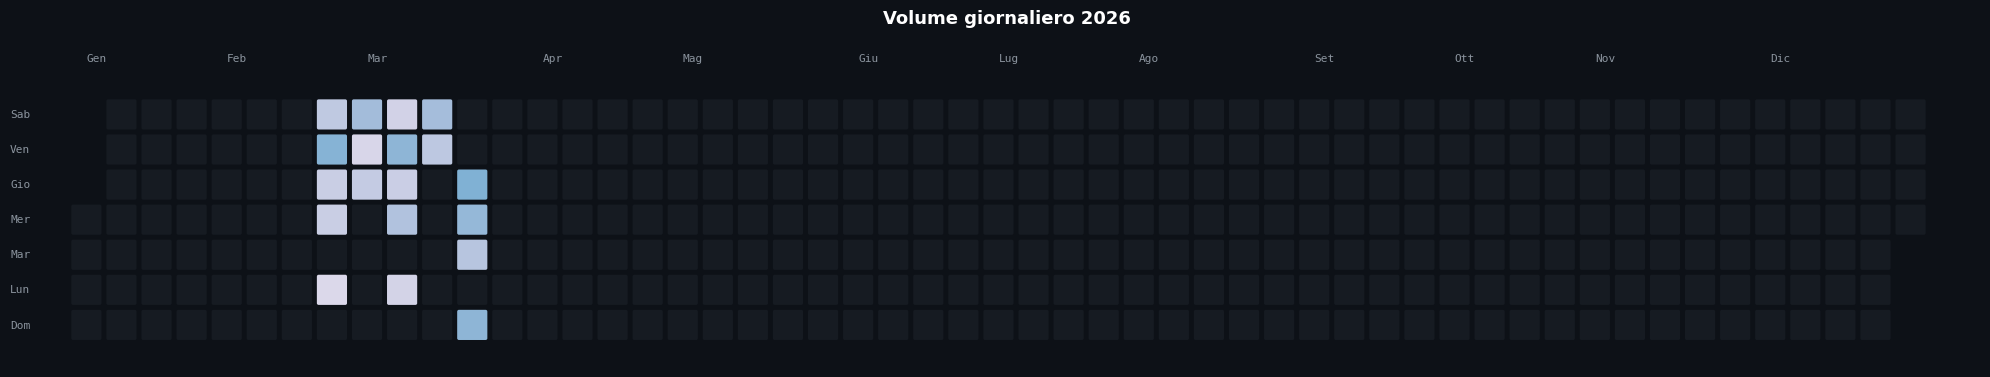

In [104]:
df['Date'] = pd.to_datetime(df['Date'])
train_2026 = df[df['Date'].dt.year == 2026].copy()

daily_counts = train_2026.groupby('Date')['Volume'].sum().reset_index(name='volume')

calendar_df = pd.DataFrame({'Date': pd.date_range('2026-01-01', '2026-12-31', freq='D')})
calendar_df = calendar_df.merge(daily_counts, on='Date', how='left')
calendar_df['volume'] = calendar_df['volume'].fillna(0).astype(float)

start_weekday = pd.Timestamp('2026-01-01').weekday()
calendar_df['week'] = ((calendar_df['Date'] - pd.Timestamp('2026-01-01')).dt.days + start_weekday) // 7
calendar_df['weekday'] = calendar_df['Date'].dt.weekday

fig, ax = plt.subplots(figsize=(20, 3.8))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')

max_val = calendar_df['volume'].max()
cmap = plt.cm.PuBuGn

for _, row in calendar_df.iterrows():
    x = row['week']
    y = 6 - row['weekday']
    val = row['volume']

    if val == 0:
        color = '#161b22'
    else:
        # Invertito: basso volume → 0.85 (scuro), alto volume → 0.2 (chiaro)
        norm = val / max_val if max_val > 0 else 0
        color = cmap(0.85 - 0.65 * norm)

    rect = mpatches.FancyBboxPatch(
        (x - 0.38, y - 0.38), 0.76, 0.76,
        boxstyle="round,pad=0.05",
        facecolor=color,
        edgecolor='none'
    )
    ax.add_patch(rect)

ax.set_xlim(-1.5, 54)
ax.set_ylim(-1.2, 8.2)
ax.set_aspect('equal')
ax.axis('off')

# Labels giorni (in italiano)
days = ['Dom', 'Lun', 'Mar', 'Mer', 'Gio', 'Ven', 'Sab']
for i, day in enumerate(days):
    ax.text(-1.6, i, day, color='#8b949e', va='center', ha='right', fontsize=8, fontfamily='monospace')

# Labels mesi
months = ['Gen', 'Feb', 'Mar', 'Apr', 'Mag', 'Giu',
          'Lug', 'Ago', 'Set', 'Ott', 'Nov', 'Dic']
for month_num, month_name in enumerate(months, start=1):
    first_day = pd.Timestamp(f'2026-{month_num:02d}-01')
    week_num = ((first_day - pd.Timestamp('2026-01-01')).days + start_weekday) // 7
    ax.text(week_num, 7.5, month_name, color='#8b949e', fontsize=8, ha='left', fontfamily='monospace')

# # Legenda volume
# legend_x = 46
# legend_y = -0.9
# ax.text(legend_x, legend_y - 0.3, 'meno', color='#8b949e', fontsize=7, ha='center', fontfamily='monospace')
# ax.text(legend_x + 4, legend_y - 0.3, 'più', color='#8b949e', fontsize=7, ha='center', fontfamily='monospace')
# for i, intensity in enumerate([0.85, 0.70, 0.55, 0.40, 0.25]):
#     rect = mpatches.FancyBboxPatch(
#         (legend_x + i * 0.85, legend_y), 0.76, 0.76,
#         boxstyle="round,pad=0.05",
#         facecolor=cmap(intensity),
#         edgecolor='none'
#     )
#     ax.add_patch(rect)

ax.set_title("Volume giornaliero 2026", color='white', pad=10, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('assets/volume_giornaliero.svg', bbox_inches='tight', facecolor='#0d1117')
plt.show()


### aggregazione muscoli primari e secondari in gruppi muscolari e rappresentazione tramite istogramma dei macro gruppi muscolari stacked con i sottogruppi


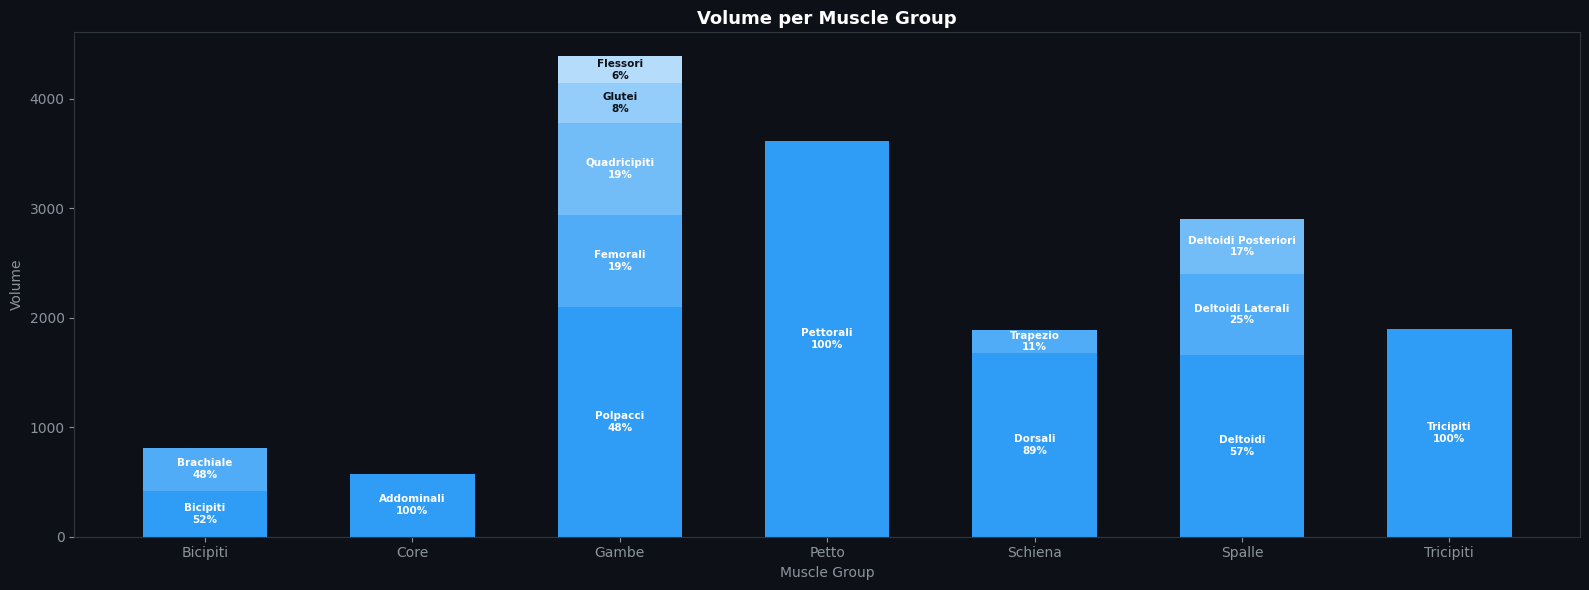

,Sets,Weight,Reps,Date,Split,Muscle Group,Secondary Muscle,Primary Muscle,Equipment,Exercise,Volume,Vol_Primary,Vol_Secondary
67,5,87.60,3,2026-03-18,Push,Tricipiti,Tricipiti,Pettorali,Bodyweight,Dips,1314.00,919.800,394.200
68,3,40.00,5,2026-03-18,Push,Spalle,Tricipiti,Deltoidi,Bilanciere,Military Press,600.00,420.000,180.000
69,2,22.00,12,2026-03-18,Push,Spalle,None,Deltoidi Laterali,Manubri,Lateral Raises,528.00,369.600,158.400
70,2,20.00,12,2026-03-18,Push,Tricipiti,None,Tricipiti,Cavi,Tricipiti Cavi,480.00,336.000,144.000
71,4,50.00,6,2026-03-18,Push,Petto,Deltoidi,Pettorali,Bilanciere,Panca Piana,1200.00,840.000,360.000
72,3,22.78,12,2026-03-19,Pull,Core,Flessori,Addominali,Bodyweight,Leg Raise,820.08,574.056,246.024
73,4,54.00,5,2026-03-19,Pull,Schiena,None,Dorsali,Bilanciere,Rematore Bilanciere,1080.00,756.000,324.000
74,5,87.60,3,2026-03-19,Pull,Schiena,Brachiale,Dorsali,Bodyweight,Hammer Pullups,1314.00,919.800,394.200
75,2,30.00,10,2026-03-19,Pull,Bicipiti,None,Bicipiti,Bilanciere,Curl Bilanciere,600.00,420.000,180.000
76,3,20.00,12,2026-03-19,Pull,Spalle,Trapezio,Deltoidi Posteriori,Cavi,Face Pull,720.00,504.000,216.000


In [107]:
muscle_to_group = {
    # Schiena
    'Dorsali': 'Schiena',
    'Trapezio': 'Schiena',
    'Romboidi': 'Schiena',
    # Spalle
    'Deltoidi': 'Spalle',
    'Deltoide Anteriore': 'Spalle',
    'Deltoidi Laterali': 'Spalle',
    'Deltoidi Posteriori': 'Spalle',
    # Petto
    'Pettorali': 'Petto',
    # Bicipiti
    'Bicipiti': 'Bicipiti',
    'Brachiale': 'Bicipiti',
    'Flessori': 'Gambe',
    # Tricipiti
    'Tricipiti': 'Tricipiti',
    # Core
    'Addominali': 'Core',
    # Gambe
    'Quadricipiti': 'Gambe',
    'Femorali': 'Gambe',
    'Glutei': 'Gambe',
    'Polpacci': 'Gambe',
}
df = df[df['Date'] >= pd.Timestamp.today() - pd.Timedelta(days=7)].copy()


df['Secondary Muscle'] = df['Secondary Muscle'].replace('—', None)
df['Vol_Primary'] = df['Volume'] * 0.70
df['Vol_Secondary'] = df['Volume'] * 0.30

primary_grouped = df.copy()
primary_grouped['Group'] = df['Primary Muscle'].map(muscle_to_group)
vol_primary = primary_grouped.groupby(['Group', 'Primary Muscle'])['Vol_Primary'].sum()

secondary_grouped = df[df['Secondary Muscle'].notna()].copy()
secondary_grouped['Group'] = secondary_grouped['Secondary Muscle'].map(muscle_to_group)
vol_secondary = secondary_grouped.groupby(['Group', 'Secondary Muscle'])['Vol_Secondary'].sum()

vol_primary.index.names = ['Group', 'Muscle']
vol_secondary.index.names = ['Group', 'Muscle']

combined = pd.concat([vol_primary, vol_secondary]).reset_index()
combined.columns = ['Group', 'Muscle', 'Volume']  # ← rinomina esplicitamente
combined = combined.groupby(['Group', 'Muscle'])['Volume'].sum().reset_index()
pivot = combined.pivot(index='Group', columns='Muscle', values='Volume').fillna(0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

base_color = "#0a8af3"  # arancione, cambia a piacere

fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')

bottom = pd.Series([0.0] * len(pivot), index=pivot.index)
# Calcola il max numero di sezioni tra tutte le colonne
max_n = max(
    len(pivot_pct.loc[g][pivot_pct.loc[g] > 0])
    for g in pivot.index
)

for group_idx, group in enumerate(pivot.index):
    row = pivot.loc[group]
    row_pct = pivot_pct.loc[group]
    
    sorted_muscles = row_pct[row_pct > 0].sort_values(ascending=False)
    b = 0.0
    
    for i, (muscle, pct) in enumerate(sorted_muscles.items()):
        val = row[muscle]
        
        # Usa max_n invece di n per avere scala uniforme
        lightness = 0.15 + 0.55 * (i / max(max_n - 1, 1))
        color = tuple(min(1, c + lightness * (1 - c)) for c in mcolors.to_rgb(base_color))
        
        ax.bar(group_idx, val, bottom=b, color=color, width=0.6)
        
        if pct > 5:
            text_color = 'white' if lightness < 0.45 else '#0d1117'
            ax.text(group_idx, b + val / 2, f'{muscle}\n{pct:.0f}%',
                    ha='center', va='center', fontsize=7.5,
                    color=text_color, fontweight='bold')
        b += val




ax.set_xticks(range(len(pivot.index)))
ax.set_xticklabels(pivot.index, color='#8b949e')
ax.set_title('Volume per Muscle Group', color='white', fontsize=13, fontweight='bold')
ax.set_xlabel('Muscle Group', color='#8b949e')
ax.set_ylabel('Volume', color='#8b949e')
ax.tick_params(colors='#8b949e')
for spine in ax.spines.values():
    spine.set_edgecolor('#30363d')

plt.tight_layout()
plt.savefig('assets/volume_muscle_group.svg', bbox_inches='tight', facecolor='#0d1117')
plt.show()
df


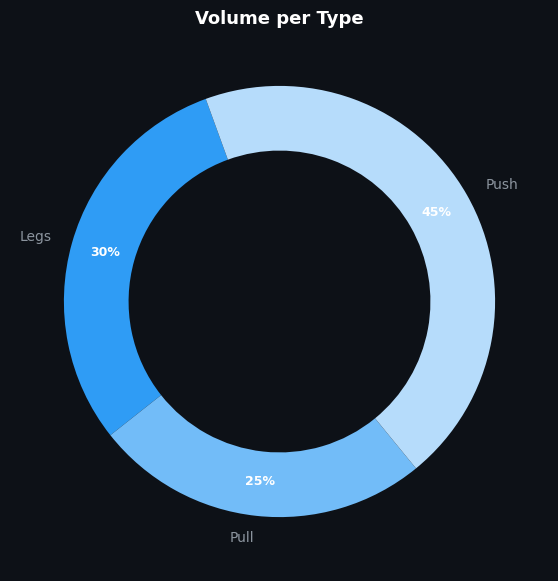

In [115]:
# Filtra null e raggruppa per Split
df_type = df[df['Split'].notna()].copy()
vol_type = df_type.groupby('Split')['Volume'].sum()

# Genera sfumature dal base_color
n = len(vol_type)
colors = [
    tuple(min(1, c + (0.15 + 0.55 * (i / max(n - 1, 1))) * (1 - c)) for c in mcolors.to_rgb(base_color))
    for i in range(n)
]

fig, ax = plt.subplots(figsize=(7, 7))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')

wedges, texts, autotexts = ax.pie(
    vol_type,
    labels=vol_type.index,
    autopct='%1.0f%%',
    colors=colors,
    pctdistance=0.84,
    wedgeprops=dict(width=0.3),  # donut
    startangle=110
)

for t in texts:
    t.set_color('#8b949e')
    t.set_fontsize(10)
for at in autotexts:
    at.set_color('white')
    at.set_fontweight('bold')
    at.set_fontsize(9)

ax.set_title('Volume per Type', color='white', fontsize=13, fontweight='bold')

plt.savefig('assets/volume_per_type.svg', bbox_inches='tight', facecolor='#0d1117')
plt.show()
